In [2]:
import torch
print(torch.cuda.is_available())   

True
Tesla T4


In [3]:
# !pip install kagglehub
import kagglehub

path = kagglehub.dataset_download("quangtheng/garbage-classification-6-classes-775class")
# print("Path to dataset files:", path)

100%|██████████| 50.2M/50.2M [00:00<00:00, 159MB/s] 

Extracting files...


In [4]:
import os

for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    indent = ' ' * 2 * level
    print(f'{indent}{os.path.basename(root)}/')
    if level == 1:
        print(f'{indent}  → {len(files)} images')

8/
  glass/
    → 775 images
  battery/
    → 775 images
  organic/
    → 775 images
  metal/
    → 775 images
  plastic/
    → 775 images
  paper/
    → 775 images


# Library

In [5]:
import torch as nn

In [6]:
import torch

print("CUDA available:", torch.cuda.is_available())
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

CUDA available: True
Using device: cuda


# Transforms & DataLoader

In [7]:
import random 
from torchvision import datasets
from torch.utils.data import Subset, DataLoader
import torchvision.transforms as transforms

train_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(path, transform=train_transform)
val_dataset   = datasets.ImageFolder(path, transform=val_transform)

total = len(train_dataset)
indices = list(range(total))
random.seed(42)     #same split every time
random.shuffle(indices)

val_size = int(0.2 * total)
train_indices = indices[val_size:]
val_indices   = indices[:val_size]

train_loader = DataLoader(Subset(train_dataset, train_indices), batch_size=32, shuffle=True)
val_loader   = DataLoader(Subset(val_dataset,   val_indices),   batch_size=32, shuffle=False)

print(f"Classes:      {train_dataset.classes}")
print(f"Total images: {total}")
print(f"Train size:   {len(train_indices)}")
print(f"Val size:     {len(val_indices)}")


Classes:      ['battery', 'glass', 'metal', 'organic', 'paper', 'plastic']
Total images: 4650
Train size:   3720
Val size:     930


# Visualize Sample Images:


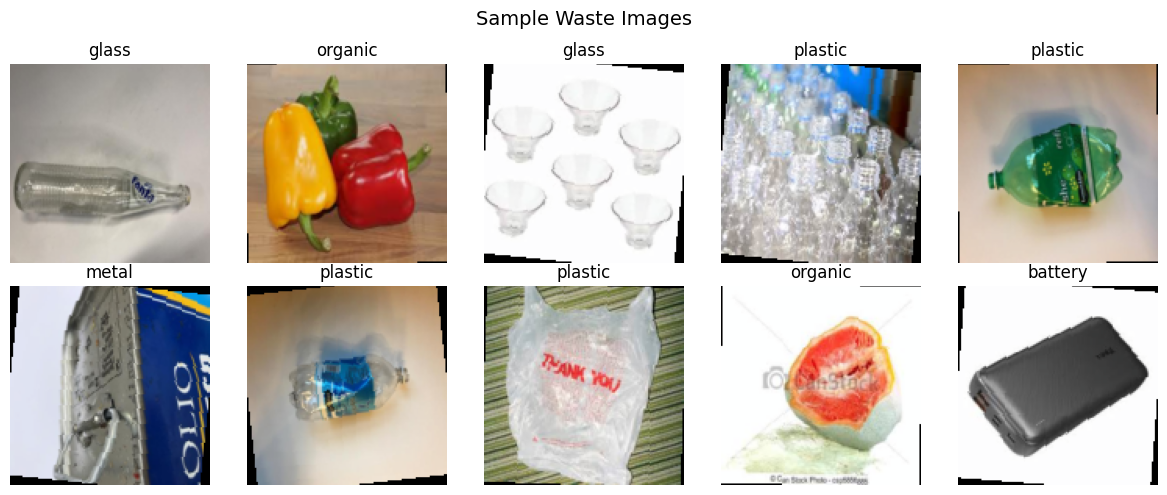

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# Denormalize for display
def denormalize(tensor):
    mean = np.array([0.485, 0.456, 0.406])
    std  = np.array([0.229, 0.224, 0.225])
    img = tensor.permute(1,2,0).numpy()     #helps to change dimention
    img = std * img + mean
    img = np.clip(img, 0 , 1)
    return img

images, labels = next(iter(train_loader))
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
fig.suptitle("Sample Waste Images", fontsize=14)

for i, ax in enumerate(axes.flatten()):
    ax.imshow(denormalize(images[i]))
    ax.set_title(train_dataset.classes[labels[i]])
    ax.axis('off')

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()



In [9]:
import torch.nn as nn

class WasteCNN(nn.Module):
    def __init__(self, num_classes=6):
        super().__init__()

        # Convolution Block 1
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolution Block 2
        self.conv2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),        #as spatial size shrinks, increase channels/features
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Convolution Block 3
        self.conv3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        # Fully Connected Layers
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 16 * 16, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self,x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.fc(x)
        return x
    
model = WasteCNN(num_classes=6).to(device)
print(model)
print(f"\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}")

WasteCNN(
  (conv1): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv3): Sequential(
    (0): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (fc): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=32768, out_features=256, b

# Training Setup

In [10]:
import torch.optim as optim

learning_rate = 0.001

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

In [11]:
%pip install mlflow

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.2/49.2 kB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 6.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 119.7 MB/s eta 0:00:0000:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 123.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 82.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 147.8/147.8 kB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 15.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 208.4/208.4 kB 26.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.0/77.0 kB 9.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 132.2/132.2 kB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 892.1/892.1 kB 66.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [13]:
import mlflow
import os
import mlflow.pytorch
from datetime import datetime

mlflow.set_experiment("waste-classification-cnn")

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
os.makedirs("models", exist_ok=True)
best_model_path = f"models/best_model_{timestamp}.pth"

EPOCHS = 20
PATIENCE = 4

best_acc = 0
patience_counter = 0

train_losses = []
train_accuracy = []
val_accuracies = []
val_losses = []

with mlflow.start_run(run_name=f"wasteCNN_dropout0.3_lr{learning_rate}"):

    mlflow.log_params({
        "epochs": EPOCHS,
        "learning_rate": learning_rate,
        "dropout": 0.3,
    })

    for epoch in range(EPOCHS):
        model.train()
        running_loss, correct = 0, 0
        
        for images, labels in (train_loader):
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            correct += (output.argmax(1) == labels).sum().item()

        train_acc = correct / len(train_indices) * 100
        train_accuracy.append(train_acc)

        avg_loss = running_loss / len(train_loader)
        train_losses.append(avg_loss)

        model.eval()
        val_loss_total, val_correct = 0, 0

        with torch.no_grad():
            for images, labels in (val_loader):
                images, labels = images.to(device), labels.to(device)
                output = model(images)
                loss = criterion(output, labels)

                val_loss_total += loss.item()
                val_correct    += (output.argmax(1) == labels).sum().item()

        val_acc = val_correct / len(val_indices) * 100
        val_accuracies.append(val_acc)

        val_loss = val_loss_total / len(val_loader)
        val_losses.append(val_loss)

        mlflow.log_metrics({
            "train_loss": avg_loss,
            "train_acc":  train_acc,
            "val_loss":   val_loss,
            "val_acc":    val_acc
        }, step=epoch)

        print(f"Epoch {epoch+1}/{EPOCHS}| Train Acc: {train_acc:.4f} | Train Loss: {avg_loss:.4f} | Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f}")
        if val_acc > best_acc:
            best_acc = val_acc
            patience_counter = 0
            torch.save(model.state_dict(), best_model_path)
        else:
            patience_counter += 1
            
        if patience_counter >= PATIENCE:
            print(f"\n Early stopping at epoch {epoch+1}")
            break

    model.load_state_dict(torch.load(best_model_path))   
    mlflow.pytorch.log_model(model, name="best_model")
    mlflow.log_metric("best_accuracy", best_acc)
    print("\n Training Complete!")

Epoch 1/20| Train Acc: 72.7957 | Train Loss: 0.7093 | Val Loss: 0.8738 | Val Acc: 69.2473
Epoch 2/20| Train Acc: 72.2043 | Train Loss: 0.7121 | Val Loss: 0.8203 | Val Acc: 74.5161
Epoch 3/20| Train Acc: 73.6022 | Train Loss: 0.7062 | Val Loss: 0.7737 | Val Acc: 74.6237
Epoch 4/20| Train Acc: 73.7634 | Train Loss: 0.6828 | Val Loss: 0.8057 | Val Acc: 74.8387
Epoch 5/20| Train Acc: 74.3548 | Train Loss: 0.6593 | Val Loss: 0.8102 | Val Acc: 77.4194
Epoch 6/20| Train Acc: 74.9462 | Train Loss: 0.6418 | Val Loss: 0.7992 | Val Acc: 77.3118
Epoch 7/20| Train Acc: 74.7581 | Train Loss: 0.6490 | Val Loss: 0.7949 | Val Acc: 74.1935
Epoch 8/20| Train Acc: 75.8065 | Train Loss: 0.6392 | Val Loss: 0.7983 | Val Acc: 75.5914
Epoch 9/20| Train Acc: 76.2634 | Train Loss: 0.6265 | Val Loss: 0.7348 | Val Acc: 77.7419
Epoch 10/20| Train Acc: 75.9140 | Train Loss: 0.6319 | Val Loss: 0.8205 | Val Acc: 75.9140
Epoch 11/20| Train Acc: 76.3710 | Train Loss: 0.6033 | Val Loss: 0.8477 | Val Acc: 77.5269
Epoch 12

2026/05/21 11:31:44 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.
2026/05/21 11:31:44 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.


Epoch 13/20| Train Acc: 78.1183 | Train Loss: 0.5783 | Val Loss: 0.8506 | Val Acc: 74.4086

 Early stopping at epoch 13


2026/05/21 11:31:49 WARNING mlflow.utils.requirements_utils: Found torch version (2.10.0+cu128) contains a local version label (+cu128). MLflow logged a pip requirement for this package as 'torch==2.10.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.



 Training Complete!
